# FACS Depletion Curves vs HD DIT-HAP

Overlay per-gene FACS depletion curves (2 strain replicates) with the corresponding HD DIT-HAP gene-level LFC curve. One subplot per gene.

In [7]:
import os
import subprocess
import sys
from pathlib import Path

# Resolve repo root via git so all relative paths work regardless of kernel CWD
_repo_root = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workflow.src.data_config import load_dataset_config

In [8]:
# HD DIT-HAP generation values (from projects/HD_DIT_HAP/config/config.yaml time_points)
HD_GENERATIONS = [0.0, 2.352, 5.588, 9.104, 12.480]
HD_LFC_COLS = ["YES0", "YES1", "YES2", "YES3", "YES4"]

FACS_PATH = "resources/curated/FACS_depletion_curves_from_XH.xlsx"
MPLSTYLE = "config/DIT_HAP.mplstyle"

In [9]:
# Load data
facs_df = pd.read_excel(FACS_PATH)

cfg = load_dataset_config("HD_DIT_HAP")
hd_lfc_df = pd.read_csv(cfg.gene_level.LFCs, sep="\t")

print("FACS genes:", sorted(facs_df["Name"].unique().tolist()))
print("HD DIT-HAP shape:", hd_lfc_df.shape)

FACS genes: ['arg6', 'cut8', 'eca39', 'fal1', 'hom6', 'leu1', 'orc6', 'rpl3601', 'sds23', 'srb4']
HD DIT-HAP shape: (4513, 9)


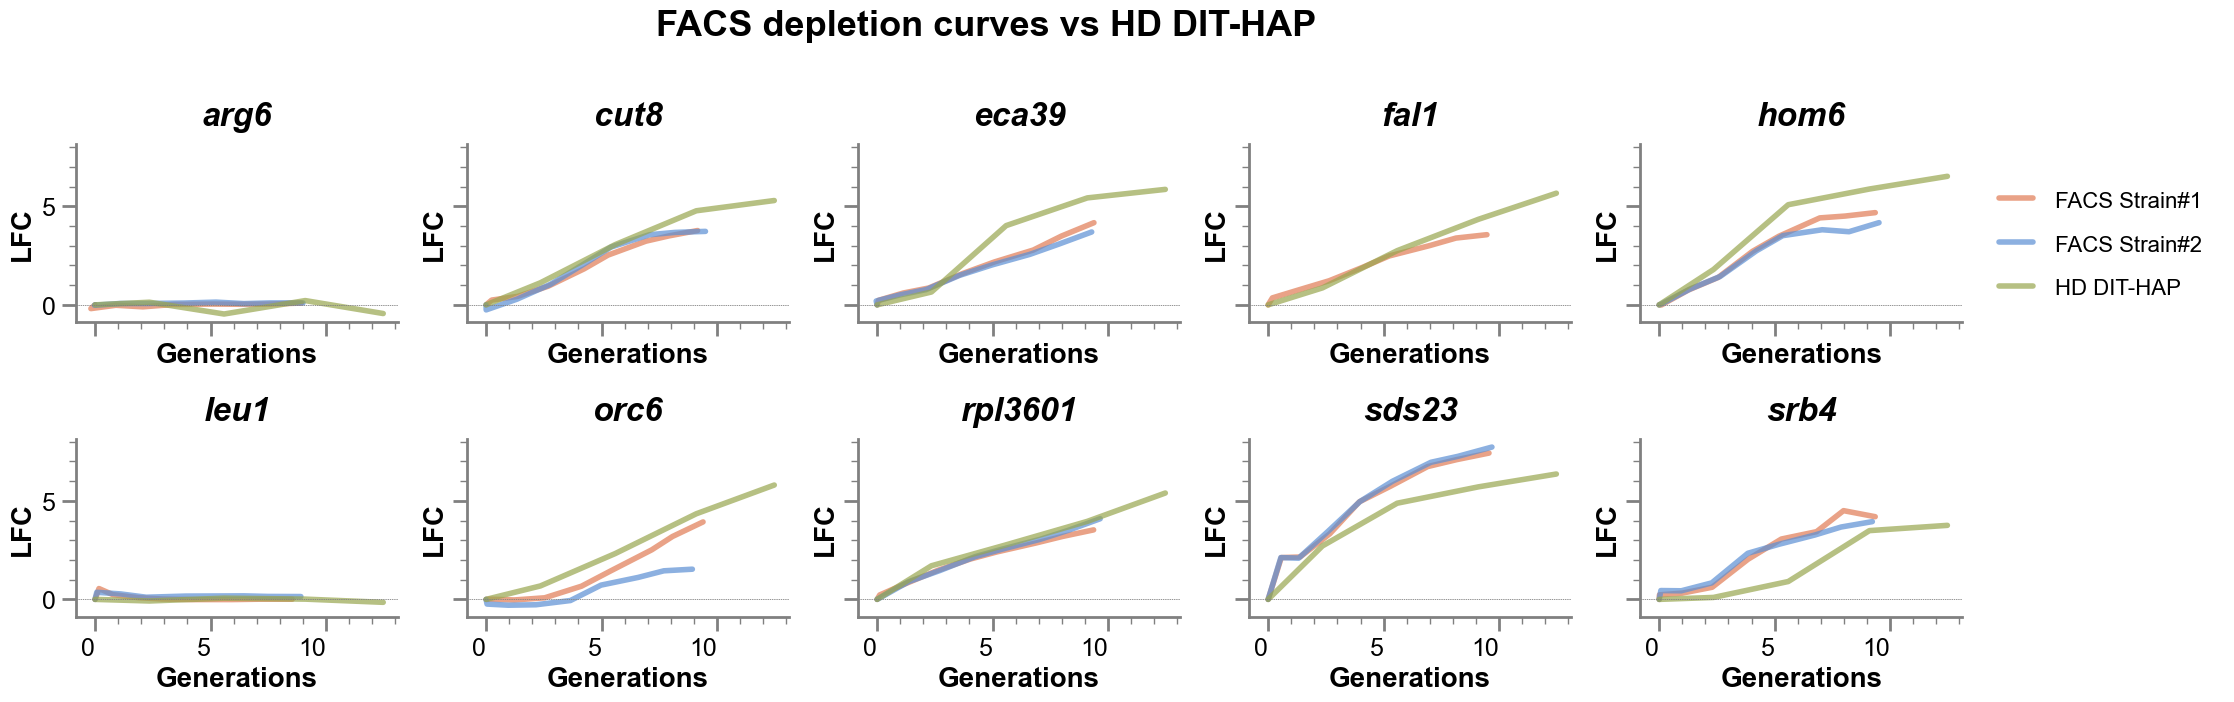

In [24]:
plt.style.use(MPLSTYLE)

genes = sorted(facs_df["Name"].unique().tolist())
n_cols = 5
n_rows = int(np.ceil(len(genes) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

FACS_COLORS = ["#e07b54", "#5b8fd4"]
HD_COLOR = "#98a64e"

for idx, gene in enumerate(genes):
    ax = axes[idx]

    # --- FACS curves ---
    gene_facs = facs_df[facs_df["Name"] == gene]
    for color, (alias, strain_df) in zip(FACS_COLORS, gene_facs.groupby("Strain_alias", sort=True)):
        ax.plot(
            strain_df["Generations"],
            strain_df["LFC"],
            color=color,
            label=f"FACS {alias}",
            alpha=0.7,
        )

    # --- HD DIT-HAP curve ---
    gene_hd = hd_lfc_df[hd_lfc_df["Name"] == gene]
    if not gene_hd.empty:
        hd_lfc_values = gene_hd[HD_LFC_COLS].values.flatten().tolist()
        ax.plot(
            HD_GENERATIONS,
            hd_lfc_values,
            color=HD_COLOR,
            label="HD DIT-HAP",
            alpha=0.7,
        )

    ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
    ax.set_title(gene, fontweight="bold", fontstyle="italic")
    ax.set_xlabel("Generations")
    ax.set_ylabel("LFC")
    # Remove per-subplot legend: ax.legend(frameon=False)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# --- Shared legend on the right side ---
strain_aliases = sorted(facs_df["Strain_alias"].unique())
legend_handles = [
    plt.Line2D([0], [0], color=FACS_COLORS[0], alpha=0.7),
    plt.Line2D([0], [0], color=FACS_COLORS[1], alpha=0.7),
    plt.Line2D([0], [0], color=HD_COLOR, alpha=0.7),
]
legend_labels = [f"FACS {a}" for a in strain_aliases] + ["HD DIT-HAP"]
fig.legend(
    legend_handles, legend_labels,
    loc="upper left", bbox_to_anchor=(0.99, 0.8),
    frameon=False,
)

fig.suptitle("FACS depletion curves vs HD DIT-HAP", y=1.01)
plt.tight_layout()  # leave 15% width for legend on the right
plt.savefig("notebooks/validation/facs_vs_dit_hap.pdf", bbox_inches="tight")
plt.show()
plt.close()